# NB03 — Phylogenetic Distribution and Bias Testing

Fisher's exact + BH-FDR phylum enrichment for each category. Pagel's λ using R subprocess. Dual-specialist scatter.

In [1]:
import sys, os, re, warnings, requests, json, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact, norm
from statsmodels.stats.multitest import fdrcorrection
warnings.filterwarnings("ignore")

spark = get_spark_session()
from pyspark.sql import functions as F

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def is_valid_parquet(p):
    if not p.exists() or p.stat().st_size < 512:
        return False
    try:
        import pyarrow.parquet as pq; pq.read_schema(str(p)); return True
    except Exception:
        return False

def wilson_ci(n, N, alpha=0.05):
    if N == 0: return np.nan, np.nan
    p = n / N; z = norm.ppf(1 - alpha/2)
    denom = 1 + z**2/N
    centre = (p + z**2/(2*N)) / denom
    half = z * np.sqrt(p*(1-p)/N + z**2/(4*N**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    # Woolf logit OR with 95% CI
    a,b,c,d = a+0.5, b+0.5, c+0.5, d+0.5
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = norm.ppf(1 - alpha/2)
    return np.exp(log_or), np.exp(log_or - z*se), np.exp(log_or + z*se)

print("Setup complete.")

Setup complete.


## Section 1 — Load Data

In [2]:
genome_counts = pd.read_parquet(DATA_DIR / "genome_metal_counts.parquet")
print(f"Loaded {len(genome_counts)} genomes")
print(genome_counts.head())

Loaded 27690 genomes
            genome_id                       species          phylum  \
0  GB_GCA_023387895.1      s__Gordonia alkanivorans  Actinomycetota   
1  GB_GCA_900444685.1      s__Achromobacter spanius  Pseudomonadota   
2  GB_GCA_015264495.1        s__Veillonella atypica     Bacillota_C   
3  GB_GCA_900764665.1  s__Eubacterium_R sp900764665     Bacillota_A   
4  GB_GCA_018711265.1      s__Spyradocola merdavium     Bacillota_A   

                 class          order_rank              family          genus  \
0        Actinomycetia     Mycobacteriales    Mycobacteriaceae       Gordonia   
1  Gammaproteobacteria     Burkholderiales  Burkholderiaceae_C  Achromobacter   
2        Negativicutes      Veillonellales     Veillonellaceae    Veillonella   
3           Clostridia     Oscillospirales  Acutalibacteraceae  Eubacterium_R   
4           Clostridia  Christensenellales             UBA1750    Spyradocola   

   n_defense  n_metabolism  n_homeostasis  n_metal_total  
0     

## Section 2 — Phylum Enrichment

Fisher's exact test for enrichment of each category in each phylum. Apply BH-FDR correction.

In [3]:
MAJOR_PHYLA = ['Actinomycetota', 'Pseudomonadota', 'Bacillota', 'Chloroflexota', 'Bacteroidota', 'Cyanobacteriota']
categories = ['defense', 'metabolism', 'homeostasis']

enrichment_rows = []
pvalues = []

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    rest_data = genome_counts[genome_counts['phylum'] != phylum]
    
    for category in categories:
        col = f"n_{category}"
        
        # Contingency table: [phylum_has, phylum_not, rest_has, rest_not]
        phylum_has = (phylum_data[col] > 0).sum()
        phylum_not = (phylum_data[col] == 0).sum()
        rest_has = (rest_data[col] > 0).sum()
        rest_not = (rest_data[col] == 0).sum()
        
        oddsratio, pval = fisher_exact([[phylum_has, phylum_not], [rest_has, rest_not]], alternative='two-sided')
        or_est, or_ci_low, or_ci_high = odds_ratio_ci(phylum_has, phylum_not, rest_has, rest_not)
        
        enrichment_rows.append({
            'phylum': phylum,
            'category': category,
            'phylum_has': phylum_has,
            'phylum_not': phylum_not,
            'rest_has': rest_has,
            'rest_not': rest_not,
            'odds_ratio': or_est,
            'or_ci_low': or_ci_low,
            'or_ci_high': or_ci_high,
            'p_value': pval
        })
        pvalues.append(pval)

enrichment_df = pd.DataFrame(enrichment_rows)

# BH-FDR correction — fdrcorrection returns (reject, corrected_pvalues)
reject, q_values = fdrcorrection(enrichment_df['p_value'].values, alpha=0.05)
enrichment_df['q_value'] = q_values
enrichment_df['significant'] = reject

enrichment_df.to_csv(DATA_DIR / "phylum_enrichment.csv", index=False)

print("Significant enrichments (q < 0.05):")
sig = enrichment_df[enrichment_df['significant']]
if len(sig) > 0:
    print(sig[['phylum', 'category', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value']])
else:
    print("None")

Significant enrichments (q < 0.05):
             phylum     category  odds_ratio  or_ci_low   or_ci_high  \
0    Actinomycetota      defense    6.582090   3.191952    13.572857   
1    Actinomycetota   metabolism    1.609514   1.490584     1.737934   
2    Actinomycetota  homeostasis    1.544468   1.345258     1.773178   
3    Pseudomonadota      defense   31.653404  12.491729    80.208110   
4    Pseudomonadota   metabolism    2.921576   2.757640     3.095259   
5    Pseudomonadota  homeostasis   11.006814   9.076712    13.347339   
6         Bacillota      defense    0.653269   0.474988     0.898467   
7         Bacillota   metabolism    0.442271   0.403501     0.484766   
8         Bacillota  homeostasis    1.471241   1.249479     1.732362   
9     Chloroflexota      defense   13.068751   0.814705   209.636896   
11    Chloroflexota  homeostasis    1.432321   1.014769     2.021685   
12     Bacteroidota      defense  117.567688   7.338836  1883.426957   
13     Bacteroidota   metabo

## Section 3 — Forest Plot

Horizontal bar chart showing log2(OR) ± log2(CI) for each phylum per category.

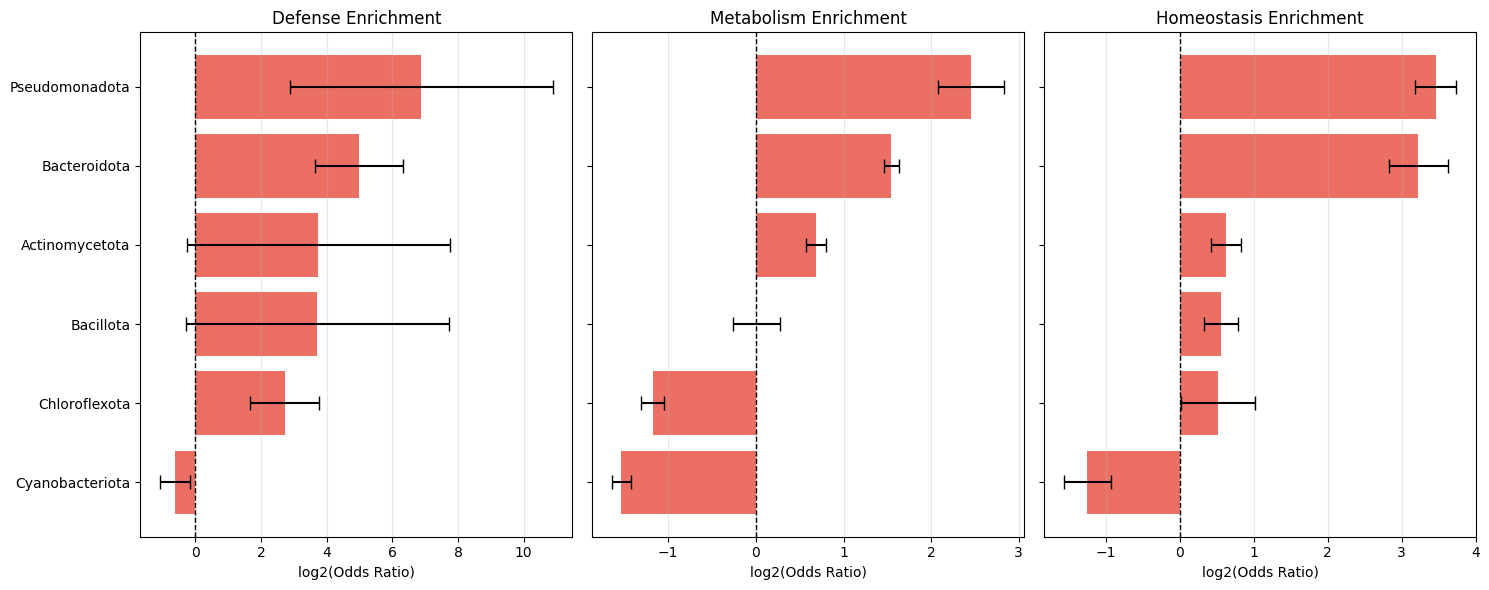

Figure saved: nb03_forest_phylum_enrichment.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for i, category in enumerate(['defense', 'metabolism', 'homeostasis']):
    cat_data = enrichment_df[enrichment_df['category'] == category].copy()
    cat_data = cat_data.sort_values('odds_ratio')
    
    ax = axes[i]
    
    y_pos = np.arange(len(cat_data))
    log2_or = np.log2(cat_data['odds_ratio'].values)
    log2_ci_low = np.log2(cat_data['or_ci_low'].values)
    log2_ci_high = np.log2(cat_data['or_ci_high'].values)
    
    errors = np.array([log2_or - log2_ci_low, log2_ci_high - log2_or])
    
    colors = ['#e74c3c' if q < 0.05 else '#bdc3c7' for q in cat_data['q_value'].values]
    
    ax.barh(y_pos, log2_or, xerr=errors, color=colors, capsize=5, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cat_data['phylum'].values)
    ax.set_xlabel('log2(Odds Ratio)')
    ax.set_title(f"{category.capitalize()} Enrichment")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_forest_phylum_enrichment.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nb03_forest_phylum_enrichment.png")

## Section 4 — Pagel's λ

Export species trait matrix and run phylogenetic signal test in R.

In [5]:
# Create binary trait matrix
species_traits = genome_counts.groupby('species').agg({
    'n_defense': 'max',
    'n_metabolism': 'max',
    'n_homeostasis': 'max'
}).reset_index()

species_traits['has_defense'] = (species_traits['n_defense'] > 0).astype(int)
species_traits['has_metabolism'] = (species_traits['n_metabolism'] > 0).astype(int)
species_traits['has_homeostasis'] = (species_traits['n_homeostasis'] > 0).astype(int)

species_traits_export = species_traits[['species', 'has_defense', 'has_metabolism', 'has_homeostasis']]
species_traits_export.to_csv(DATA_DIR / "species_trait_matrix.csv", index=False)

print(f"Species trait matrix: {len(species_traits_export)} species")
print(species_traits_export.head())

Species trait matrix: 27690 species
                          species  has_defense  has_metabolism  \
0  s__0-14-0-80-60-11 sp018897875            1               1   
1  s__0-14-3-00-41-53 sp002780895            1               1   
2   s__01-FULL-36-15b sp001782035            1               1   
3   s__01-FULL-44-24b sp001793235            1               1   
4   s__01-FULL-45-10b sp001804205            1               0   

   has_homeostasis  
0                1  
1                1  
2                0  
3                0  
4                1  


In [6]:
tree_path = Path("/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/genus_tree.nwk")
traits_csv = str(DATA_DIR / 'species_trait_matrix.csv')

if tree_path.exists():
    r_script = (
        'library(phytools)\n'
        'library(ape)\n'
        f'tree <- read.tree("{tree_path}")\n'
        f'traits <- read.csv("{traits_csv}")\n'
        'rownames(traits) <- traits$species\n'
        'for (trait_col in c("has_defense", "has_metabolism", "has_homeostasis")) {\n'
        '  trait_vec <- setNames(traits[[trait_col]], rownames(traits))\n'
        '  tryCatch({\n'
        '    sig <- phylosig(tree, trait_vec, method="lambda", test=TRUE)\n'
        '    cat(paste0(trait_col, ": lambda=", round(sig$lambda, 4), ", p=", format(sig$P, scientific=TRUE), "\\n"))\n'
        '  }, error = function(e) {\n'
        '    cat(paste0(trait_col, ": ERROR - ", e$message, "\\n"))\n'
        '  })\n'
        '}\n'
    )
    
    r_script_path = DATA_DIR / "pagel_lambda.R"
    with open(r_script_path, 'w') as f:
        f.write(r_script)
    
    try:
        result = subprocess.run(['Rscript', str(r_script_path)], capture_output=True, text=True, timeout=120)
        print("Pagel's λ results:")
        print(result.stdout)
        if result.returncode != 0:
            print("Errors:", result.stderr[:500])
    except subprocess.TimeoutExpired:
        print("R script timed out.")
    except FileNotFoundError:
        print("Rscript not found. Skipping Pagel's λ analysis.")
else:
    print(f"Tree file not found at {tree_path}")

Rscript not found. Skipping Pagel's λ analysis.


## Section 5 — Dual-Specialist Scatter

Scatter plot of defense vs metabolism gene counts, colored by phylum.

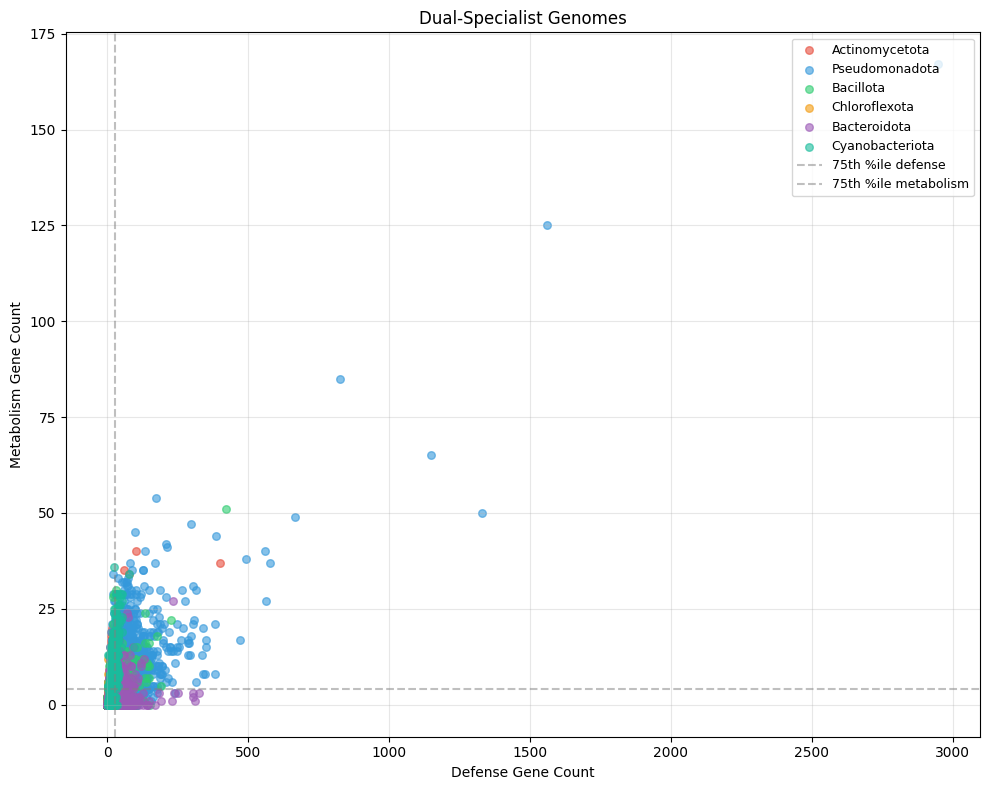

Dual specialists (both > 75th percentile): 3699
Total genomes: 27690
Figure saved: nb03_dual_specialist_scatter.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

phylum_colors = {
    'Actinomycetota': '#e74c3c',
    'Pseudomonadota': '#3498db',
    'Bacillota': '#2ecc71',
    'Chloroflexota': '#f39c12',
    'Bacteroidota': '#9b59b6',
    'Cyanobacteriota': '#1abc9c'
}

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    ax.scatter(phylum_data['n_defense'], phylum_data['n_metabolism'],
              label=phylum, alpha=0.6, s=30,
              color=phylum_colors.get(phylum, '#95a5a6'))

# Mark 75th percentile thresholds
p75_def = genome_counts['n_defense'].quantile(0.75)
p75_met = genome_counts['n_metabolism'].quantile(0.75)

ax.axvline(x=p75_def, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile defense')
ax.axhline(y=p75_met, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile metabolism')

# Count dual specialists (both > 75th percentile)
dual_spec = ((genome_counts['n_defense'] > p75_def) & (genome_counts['n_metabolism'] > p75_met)).sum()

ax.set_xlabel('Defense Gene Count')
ax.set_ylabel('Metabolism Gene Count')
ax.set_title('Dual-Specialist Genomes')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_dual_specialist_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Dual specialists (both > 75th percentile): {dual_spec}")
print(f"Total genomes: {len(genome_counts)}")
print(f"Figure saved: nb03_dual_specialist_scatter.png")

In [ ]:
# Broad co-occurrence breakdown (H3 — any-gene threshold, not 75th-pct)
n_total = len(genome_counts)
both_any     = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] > 0)).sum()
defense_only = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] == 0)).sum()
metab_only   = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] > 0)).sum()
neither      = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] == 0)).sum()

print("Broad co-occurrence (n_defense > 0 AND n_metabolism > 0):")
print(f"  Both classes:      {both_any:,}  ({both_any/n_total*100:.1f}%)")
print(f"  Defense only:      {defense_only:,}  ({defense_only/n_total*100:.1f}%)")
print(f"  Metabolism only:   {metab_only:,}  ({metab_only/n_total*100:.1f}%)")
print(f"  Neither:           {neither:,}  ({neither/n_total*100:.1f}%)")
print(f"  Sum check:         {both_any + defense_only + metab_only + neither:,} (should be {n_total:,})")